In [ ]:
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import KFold

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


In [ ]:
# Load full preprocessed data
X_scaled = np.load("../dataset/X_scaled.npy")
y = np.load("../dataset/y.npy")
target_encoder = joblib.load("../models/target_encoder.pkl")

print("Data loaded successfully.")
print("X_scaled shape:", X_scaled.shape)


Data loaded successfully.
X_scaled shape: (64983, 21)


In [ ]:
# Reshape for DL (samples, timesteps, features)
X_dl = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])
print("X_dl shape:", X_dl.shape)


X_dl shape: (64983, 1, 21)


In [ ]:
def create_lstm_model():
    model = Sequential()
    model.add(LSTM(32, return_sequences=False, kernel_regularizer=l2(0.001), input_shape=(1, X_dl.shape[2])))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation="relu", kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(Dense(3, activation="softmax"))
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def create_gru_model():
    model = Sequential()
    model.add(GRU(32, return_sequences=False, kernel_regularizer=l2(0.001), input_shape=(1, X_dl.shape[2])))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation="relu", kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(Dense(3, activation="softmax"))
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def create_cnn_lstm_model():
    model = Sequential()
    # We need to reshape slightly differently for CNN if we treat features as timesteps,
    # but we can also just apply Conv1D over the 1 timestep, which acts like a dense layer.
    # Usually CNN-LSTM expects (samples, timesteps, features) and Conv1D slides over timesteps.
    # Since timesteps=1, we can reshape to (samples, features, 1) for Conv1D to slide over features.
    pass # We will reshape internally
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_scaled.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(32, kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation="relu", kernel_regularizer=l2(0.001)))
    model.add(Dense(3, activation="softmax"))
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


In [ ]:
kf = KFold(n_splits=5, shuffle=False)
lstm_scores = []
gru_scores = []
cnn_lstm_scores = []

# Reshape for CNN-LSTM
X_cnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

stage = 1
for train_index, test_index in kf.split(X_dl):
    print(f"\n--- STAGE {stage} ---")
    
    X_train_dl, X_test_dl = X_dl[train_index], X_dl[test_index]
    X_train_cnn, X_test_cnn = X_cnn[train_index], X_cnn[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # LSTM
    lstm = create_lstm_model()
    lstm.fit(X_train_dl, y_train, epochs=50, batch_size=64, verbose=0)
    lstm_acc = accuracy_score(y_test, np.argmax(lstm.predict(X_test_dl, verbose=0), axis=1))
    lstm_scores.append(lstm_acc)
    print(f"LSTM Accuracy:      {lstm_acc:.4f}")
    
    # GRU
    gru = create_gru_model()
    gru.fit(X_train_dl, y_train, epochs=50, batch_size=64, verbose=0)
    gru_acc = accuracy_score(y_test, np.argmax(gru.predict(X_test_dl, verbose=0), axis=1))
    gru_scores.append(gru_acc)
    print(f"GRU Accuracy:       {gru_acc:.4f}")
    
    # CNN-LSTM
    cnn_lstm = create_cnn_lstm_model()
    cnn_lstm.fit(X_train_cnn, y_train, epochs=50, batch_size=64, verbose=0)
    cnn_lstm_acc = accuracy_score(y_test, np.argmax(cnn_lstm.predict(X_test_cnn, verbose=0), axis=1))
    cnn_lstm_scores.append(cnn_lstm_acc)
    print(f"CNN-LSTM Accuracy:  {cnn_lstm_acc:.4f}")
    
    stage += 1

print("\n=== AVERAGE ACCURACY ACROSS 5 STAGES ===")
print(f"LSTM Average:      {np.mean(lstm_scores):.4f}")
print(f"GRU Average:       {np.mean(gru_scores):.4f}")
print(f"CNN-LSTM Average:  {np.mean(cnn_lstm_scores):.4f}")



--- STAGE 1 ---
LSTM Accuracy:      0.8669
GRU Accuracy:       0.8600
CNN-LSTM Accuracy:  0.8600

--- STAGE 2 ---
LSTM Accuracy:      0.7783
GRU Accuracy:       0.8387
CNN-LSTM Accuracy:  0.8385

--- STAGE 3 ---
LSTM Accuracy:      0.8810
GRU Accuracy:       0.8854
CNN-LSTM Accuracy:  0.8660

--- STAGE 4 ---
LSTM Accuracy:      0.8319
GRU Accuracy:       0.8323
CNN-LSTM Accuracy:  0.8313

--- STAGE 5 ---
LSTM Accuracy:      0.8461
GRU Accuracy:       0.8324
CNN-LSTM Accuracy:  0.8500

=== AVERAGE ACCURACY ACROSS 5 STAGES ===
LSTM Average:      0.8409
GRU Average:       0.8497
CNN-LSTM Average:  0.8492


In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Final LSTM...")
final_lstm = create_lstm_model()
hist_lstm = final_lstm.fit(X_dl, y, epochs=50, batch_size=64, validation_split=0.2, callbacks=[early_stopping], verbose=1)

print("\nTraining Final GRU...")
final_gru = create_gru_model()
hist_gru = final_gru.fit(X_dl, y, epochs=50, batch_size=64, validation_split=0.2, callbacks=[early_stopping], verbose=1)

print("\nTraining Final CNN-LSTM...")
final_cnn = create_cnn_lstm_model()
hist_cnn = final_cnn.fit(X_cnn, y, epochs=50, batch_size=64, validation_split=0.2, callbacks=[early_stopping], verbose=1)


Training Final LSTM...
Epoch 1/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8027 - loss: 0.5122 - val_accuracy: 0.8846 - val_loss: 0.3368
Epoch 2/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8432 - loss: 0.3766 - val_accuracy: 0.8810 - val_loss: 0.3338
Epoch 3/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8454 - loss: 0.3558 - val_accuracy: 0.8537 - val_loss: 0.3672
Epoch 4/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8475 - loss: 0.3441 - val_accuracy: 0.8517 - val_loss: 0.3486
Epoch 5/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8492 - loss: 0.3369 - val_accuracy: 0.7916 - val_loss: 0.4099
Epoch 6/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8486 - loss: 0.3347 - val_accuracy: 0.8180 - val_loss: 0.3907
Epoch 7/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8493 - loss: 0.3312 - val_accuracy: 0.7881 - val_loss: 0.4167
Epoch 8/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8491 - loss: 0.

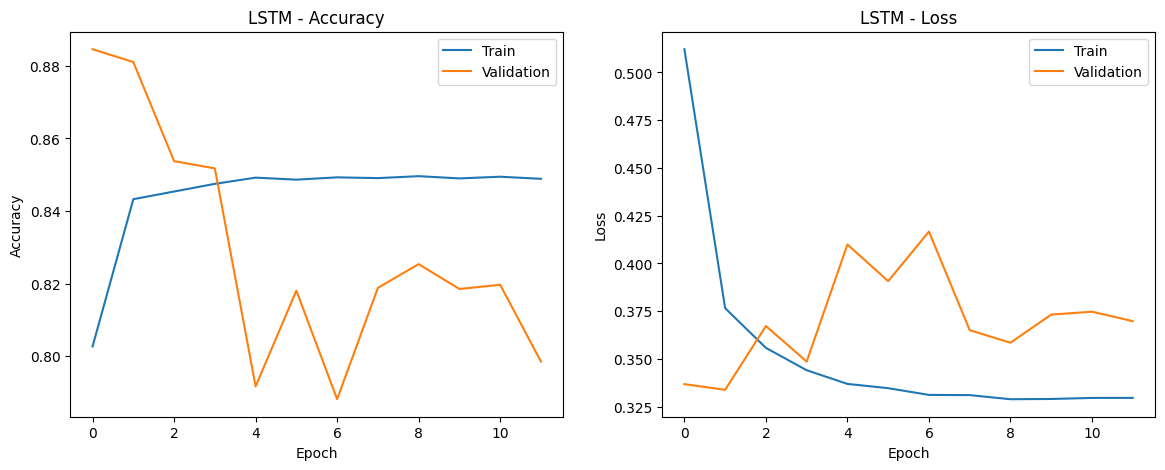

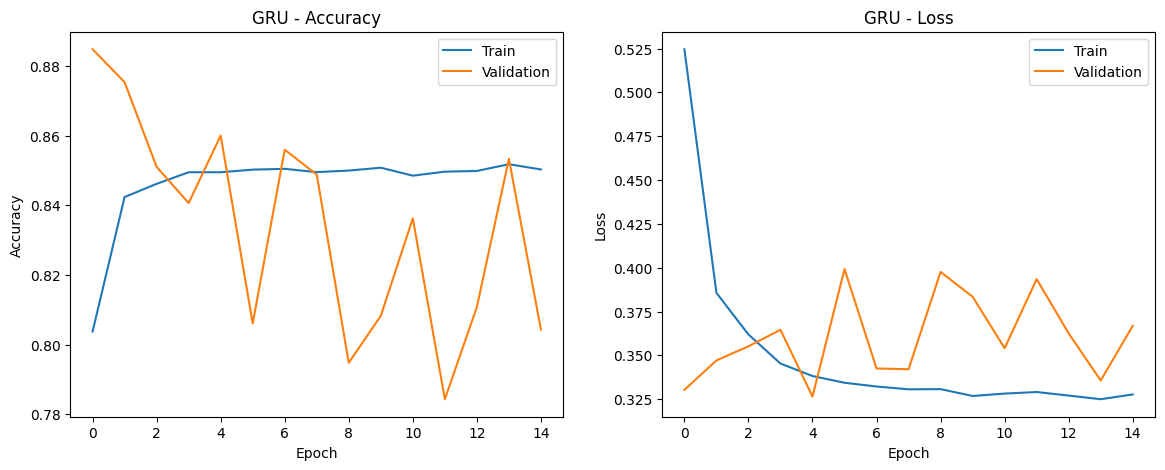

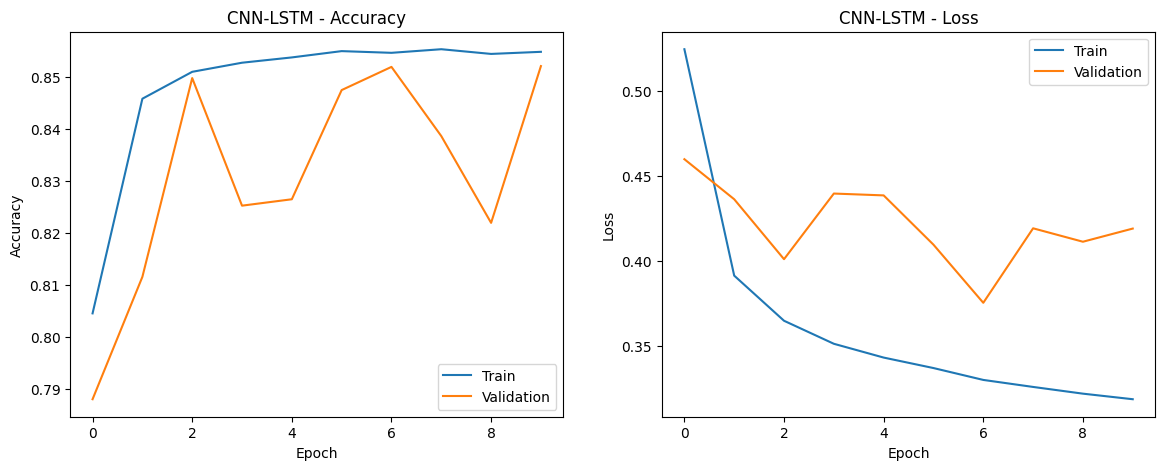

In [ ]:
def plot_dl_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    # Loss
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.show()

plot_dl_history(hist_lstm, 'LSTM')
plot_dl_history(hist_gru, 'GRU')
plot_dl_history(hist_cnn, 'CNN-LSTM')


In [ ]:
os.makedirs("../models", exist_ok=True)
final_lstm.save("../models/lstm_model.keras")
final_gru.save("../models/gru_model.keras")
final_cnn.save("../models/cnn_lstm_model.keras")
print("All Deep Learning models saved.")


All Deep Learning models saved.
